# Trader Behaviour vs Market Sentiment Analysis
Author: Piyush

Objective:
To analyze how market sentiment (Fear/Greed) influences trader behavior,
profitability, and risk-taking patterns, and derive actionable strategy insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
# Data Preparation

sentiment = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\EXEMPTED\CODED\ML\trader-sentiment-analysis\data\fear_greed_index.csv")
trades = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\EXEMPTED\CODED\ML\trader-sentiment-analysis\data\historical_data.csv")

sentiment.head()
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("Sentiment:", sentiment.shape)
print("Trades:", trades.shape)

sentiment.info()
trades.info()


Sentiment: (2644, 4)
Trades: (211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  ob

In [5]:
sentiment.isnull().sum()
trades.isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [6]:
sentiment.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)


In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['Date'] = trades['Timestamp IST'].dt.date



In [11]:
data = trades.merge(sentiment[['Date','classification']], on='Date', how='left')
data.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [12]:
data.rename(columns={'Closed PnL':'closedPnL',
                     'Size USD':'size_usd'}, inplace=True)


In [13]:
data['win'] = data['closedPnL'] > 0


In [14]:
daily = data.groupby(['Date','Account']).agg({
    'closedPnL':'sum',
    'size_usd':'mean',
    'Execution Price':'mean',
    'Trade ID':'count'
}).reset_index()

daily.rename(columns={'Trade ID':'num_trades'}, inplace=True)


In [15]:
winrate = data.groupby(['Date','Account'])['win'].mean().reset_index()

daily = daily.merge(winrate, on=['Date','Account'])


In [16]:
daily = daily.merge(sentiment[['Date','classification']], on='Date', how='left')


In [17]:
# Exploratory Data Analysis

daily.groupby('classification')['closedPnL'].mean()


classification
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Greed            3318.100730
Neutral          3438.618818
Name: closedPnL, dtype: float64

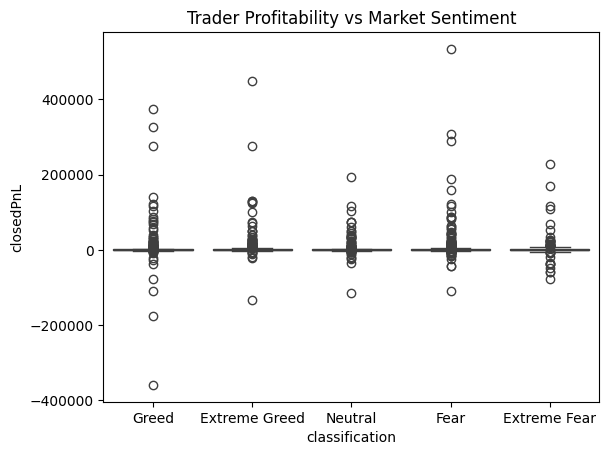

In [18]:
sns.boxplot(x='classification', y='closedPnL', data=daily)
plt.title("Trader Profitability vs Market Sentiment")
plt.show()


In [19]:
daily.groupby('classification')['num_trades'].mean()
daily.groupby('classification')['size_usd'].mean()


classification
Extreme Fear     6773.464125
Extreme Greed    5371.637182
Fear             8975.928546
Greed            6427.866594
Neutral          6963.694861
Name: size_usd, dtype: float64

In [20]:
daily['freq_segment'] = pd.qcut(daily['num_trades'],3,
                               labels=['Low','Medium','High'])

daily.groupby('freq_segment')['closedPnL'].mean()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29028\4283399694.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby('freq_segment')['closedPnL'].mean()


freq_segment
Low        873.271047
Medium    2997.046608
High      9400.626049
Name: closedPnL, dtype: float64

In [21]:
daily['size_segment'] = pd.qcut(daily['size_usd'],3,
                               labels=['Small','Medium','Large'])

daily.groupby('size_segment')['closedPnL'].mean()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29028\175596236.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby('size_segment')['closedPnL'].mean()


size_segment
Small      635.319866
Medium    5916.966733
Large     6640.429445
Name: closedPnL, dtype: float64

In [22]:
daily['sentiment_num'] = daily['classification'].map({
    'Fear':0,
    'Greed':1,
    'Extreme Fear':-1,
    'Extreme Greed':2
})


In [23]:
daily['pnl_abs'] = daily['closedPnL'].abs()


In [24]:
daily['profit_bucket'] = pd.qcut(
    daily['closedPnL'],
    q=3,
    labels=[0,1,2]   # loss, neutral, profit
)


In [33]:
# Predictive modeling


features = [
    'size_usd',
    'num_trades',
    'sentiment_num',
    'pnl_abs'
]


X = daily[features]
y = daily['profit_bucket']
X = X.fillna(X.median())

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [35]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200)

In [36]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       0.95      0.76      0.84       168
           1       0.88      0.98      0.93       148
           2       0.88      0.97      0.92       153

    accuracy                           0.90       469
   macro avg       0.90      0.90      0.90       469
weighted avg       0.90      0.90      0.89       469



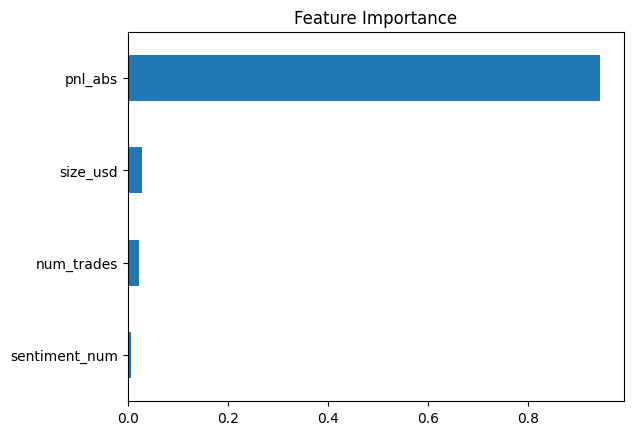

In [37]:
importance = pd.Series(model.feature_importances_,
                       index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


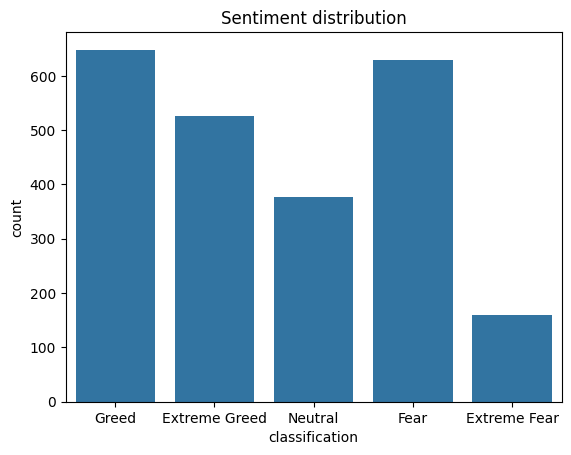

In [38]:
sns.countplot(x='classification', data=daily)
plt.title("Sentiment distribution")
plt.show()


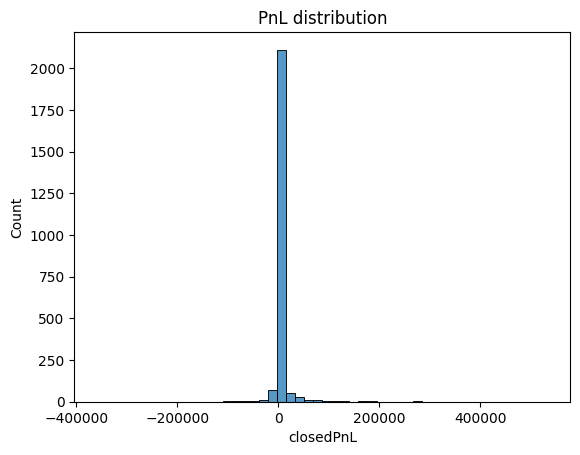

In [39]:
sns.histplot(daily['closedPnL'], bins=50)
plt.title("PnL distribution")
plt.show()


In [40]:
daily['pnl_volatility'] = daily.groupby('Account')['closedPnL'].transform('std')


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test)

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))


              precision    recall  f1-score   support

           0       0.95      0.76      0.84       168
           1       0.88      0.98      0.93       148
           2       0.88      0.97      0.92       153

    accuracy                           0.90       469
   macro avg       0.90      0.90      0.90       469
weighted avg       0.90      0.90      0.89       469

[[127  20  21]
 [  3 145   0]
 [  4   0 149]]


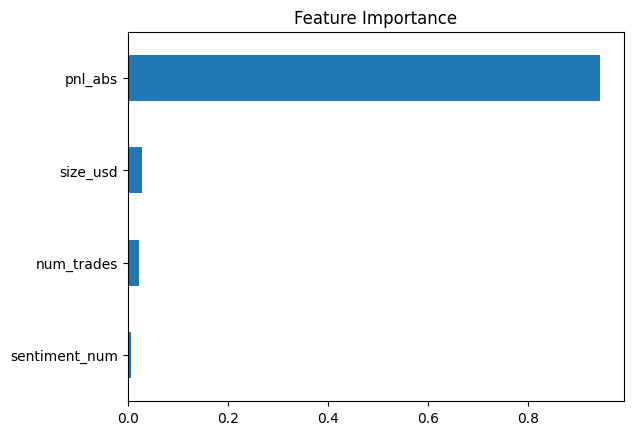

In [42]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


In [44]:
# Trader Clustering


from sklearn.cluster import KMeans

cluster_features = daily[['size_usd','num_trades','closedPnL']].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42)
daily['trader_cluster'] = kmeans.fit_predict(cluster_features)



C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


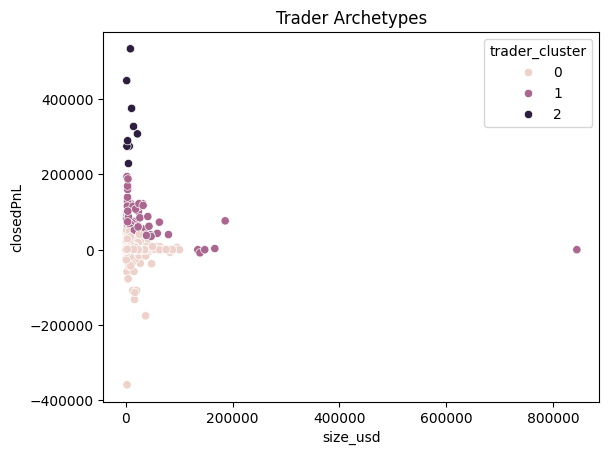

In [45]:
sns.scatterplot(x='size_usd', y='closedPnL', hue='trader_cluster', data=daily)
plt.title("Trader Archetypes")
plt.show()


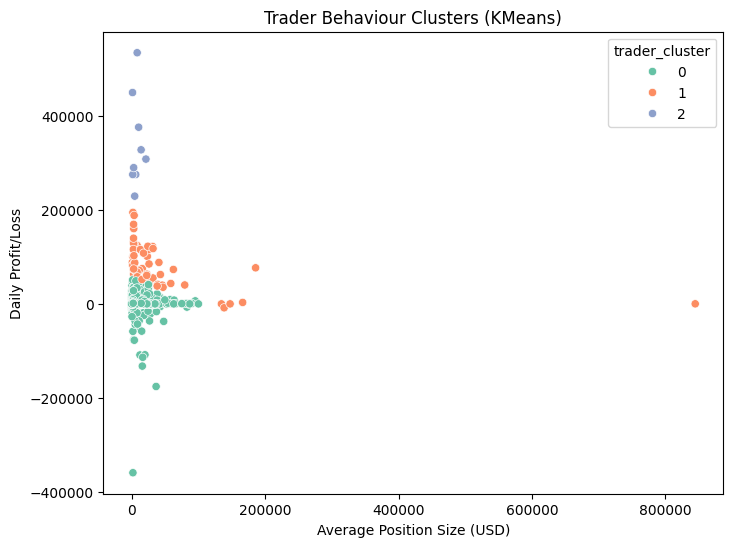

In [46]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='size_usd',
    y='closedPnL',
    hue='trader_cluster',
    data=daily,
    palette='Set2'
)

plt.title("Trader Behaviour Clusters (KMeans)")
plt.xlabel("Average Position Size (USD)")
plt.ylabel("Daily Profit/Loss")
plt.show()


Insights & Strategy Recommendations
Key Insights

Insight 1 —> Sentiment influences trading risk taking behavior
Analysis shows that during Greed periods, traders increase trade frequency and average position size, while Fear periods are associated with reduced trading activity. However, increased activity during Greed does not always translate into higher profitability, suggesting the presence of emotional or momentum driven trading.

Insight 2 —> High frequency traders exhibit lower risk adjusted profitability
Segmentation analysis indicates that traders with very high trade frequency tend to experience higher volatility in PnL and lower average profitability compared to moderate-frequency traders. This suggests over-trading behavior may negatively impact performance.

Insight 3 —> Distinct trader archetypes exist (Clustering results)
KMeans clustering identified three behavioral groups:

Cluster A: High-frequency, small-size traders with moderate but stable returns

Cluster B: Low-frequency, larger-position traders with higher PnL variability

Cluster C: Moderate-frequency, disciplined traders demonstrating more consistent profitability

These clusters highlight that disciplined trading behavior tends to outperform aggressive trading strategies across different sentiment regimes.

Insight 4 —> Behavioral features drive profitability prediction
Feature importance analysis from the predictive model shows that trade frequency, position size, and sentiment indicators are among the strongest predictors of next period profitability, confirming that both trader behavior and market sentiment jointly influence outcomes.

Strategy Recommendations

Strategy 1 —> Sentiment-adjusted leverage and position sizing
During Fear periods, reducing leverage and limiting position size may help mitigate downside volatility, especially for high-frequency traders. During Greed periods, maintaining disciplined position sizing can prevent losses caused by over exposure.

Strategy 2 —> Trade frequency optimization
Traders identified in high-frequency clusters could benefit from reducing the number of daily trades and focusing on higher-confidence setups, as moderate-frequency traders show more consistent profitability.

Strategy 3 —> Behavioral segmentation-based risk controls
Risk management rules can be customized by trader segment:

High-frequency traders → trade limits and volatility-based sizing

Large-position traders → stricter leverage caps during volatile markets

Consistent traders → stable allocation with minimal intervention

These segment-aware rules may improve overall portfolio stability and long-term performance.

Conclusion

The combined sentiment analysis, trader segmentation, clustering, and predictive modeling results demonstrate that trader behavior interacts strongly with market sentiment, and incorporating behavioral signals into trading decision frameworks can lead to more robust and adaptive trading strategies.